# Local spatial correlation between the social vulnerability of population and inundation risk of dam failure

This notebook demonstrates how the social vulnerability of the population (i.e., socially disadvantaged or non-disadvantaged) is spatially correlated with the inundation risk of a dam failure, focusing on a single dam. The analysis consists of the following two steps.
1. it identifies census blocks inundated from flooding caused by three dam failure scenarios with different water levels: normal high (NH), top of active storage (TAS), and maximum high (MH), retrived from the National Inventory of Dams (NID) of US Army Corps of Engineers. 
2. it employs two spatial correlation metrics (i.e., Bivariate Moran’s I and Bivariate Local Indicator of Spatial Association (LISA)) to investigate the relationship between the inundation risk and social vulnerability of the population per impacted locations from a single dam failure. In this context, we employed 16 census variables related to the social vulnerability index.

| Acronym | Note                            |
|---------|---------------------------------|
| POV150  | Below 150% Poverty              |
| UNEMP   | Unemployment Rate               |
| HBURD   | Housing Cost Burden             |
| NOHSDP  | No High School Diploma          |
| NOINSUR | No Health Insurance             |
| AGE65   | Aged 65 & Older                 |
| AGE17   | Aged 17 & Younger               |
| DISABL  | Civilian with a Disability      |
| SNGPNT  | Single-Parent Households        |
| LIMENG  | English Language Proficiency    |
| MINRTY  | Racial & Ethnic Minority Status |
| MUNIT   | Multi-Unit Structures           |
| MOBILE  | Mobile Homes                    |
| CROWD   | Crowding                        |
| NOVEH   | No Vehicle Household            |
| GROUPQ  | Group Quarters                  |


In [1]:
# Import necessary packages
import os
import sys
import pandas as pd
import geopandas as gpd
import subprocess
import json
import pygeos
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import libpysal
import esda
import contextily as cx

## 0. Set up environment variables


In [2]:
# Setting up Sedona


os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable


from sedona.spark import *
from pyspark.sql.functions import *
config = SedonaContext.builder(). \
    config('spark.jars.packages',
           'org.apache.sedona:sedona-spark-3.0_2.12:1.6.1,'
           'org.datasyslab:geotools-wrapper:1.6.1-28.2'). \
    config('spark.jars.repositories', 'https://artifacts.unidata.ucar.edu/repository/unidata-all'). \
    getOrCreate()
sedona = SedonaContext.create(config)

# Working directory
data_dir = './data'
output_dir = os.getcwd()

# Find the list of dams 
fed_dams = pd.read_csv('./data/dam_list.csv')
fed_dams = gpd.GeoDataFrame(fed_dams, geometry=gpd.points_from_xy(fed_dams['LON'], fed_dams['LAT'], crs="EPSG:4326"))
print(f'Total count of dams available for local analysis: {fed_dams.shape[0]}')

# Dam of Interest
dam_id = 'CA10022' # example dam for demonstrating local analysis
API_Key = '0095b927b6cd567c8bc33e956d649c3442241f69' # The API key can be obtained through https://api.census.gov/data/key_signup.html

print(f'Dam of Interest: {dam_id}')

https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/exouser/.ivy2/cache
The jars for the packages stored in: /home/exouser/.ivy2/jars
org.apache.sedona#sedona-spark-3.0_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-4666694b-0441-468f-a55b-54f188fd21f3;1.0
	confs: [default]


:: loading settings :: url = jar:file:/home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.0_2.12;1.6.1 in central
	found org.apache.sedona#sedona-common;1.6.1 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.19.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

Total count of dams available for local analysis: 345
Dam of Interest: CA10022


## 1. Find census blocks impacted by three dam failure scenarios

Spatial intersections are conducted to find the submerged census blocks from three dam failure scenarios (i.e., breach of dam structure with the water level of normal high (NH), top of active storage (TAS), and maximum high (MH)). <br> Per each scenario, <br>
1. we vectorized the original raster into a polygon and spatially queried census blocks using Boolean logic. In other words, a census block has a value of one if it intersects with the inundation polygon; otherwise, it has zero. 
2. we overlaid three polygons from three dam breach scenarios (i.e., MH, TAS, and NH) to estimate the potential risk of flooding. <br>
3. we found census blocks that intersected with the polygonized geometry and then kept the highest inundation risk value (i.e., 1~3) per census block. 

As a result, the inundation risk of a single dam failure provides polygons with values ranging from one through three.  A census block with a value of three means the location will be submerged for every scenario (NH, TAS, and MH), whereas a polygon having a value of one means that the area would only get impacted for the worst-case scenario (MH breach).

### 1.1. Vectorize inundations of three scenarios and overlaid them

Creating output file that is 197P x 137L.
Processing ./data/NID_FIM_MH_F/MH_F_CA10022.tiff [1/1] : 0Using internal nodata values (e.g. 0) for image ./data/NID_FIM_MH_F/MH_F_CA10022.tiff.
Copying nodata values from source ./data/NID_FIM_MH_F/MH_F_CA10022.tiff to destination /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/workflow/MH_F_CA10022_resample.tiff.
...10...20...30...40...50...60...70...80...90...100 - done.
--outfile=/home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/workflow/MH_F_CA10022_reclass.tiff
0...10...20...30...40...50...60...70...80...90...Several drivers matching json extension. Using GeoJSON
Creating output /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/workflow/MH_F_CA10022.json of format GeoJSON.
100 - done.
in here
Creating output file that is 190P x 129L.
Processing ./data/NID_FIM_TAS_F/TAS_F_CA10022.tiff [1/1] : 0Using internal nodata values (e.g. 0) for image ./data/NID_FIM_TA

ERROR 1: PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


CRSError: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.

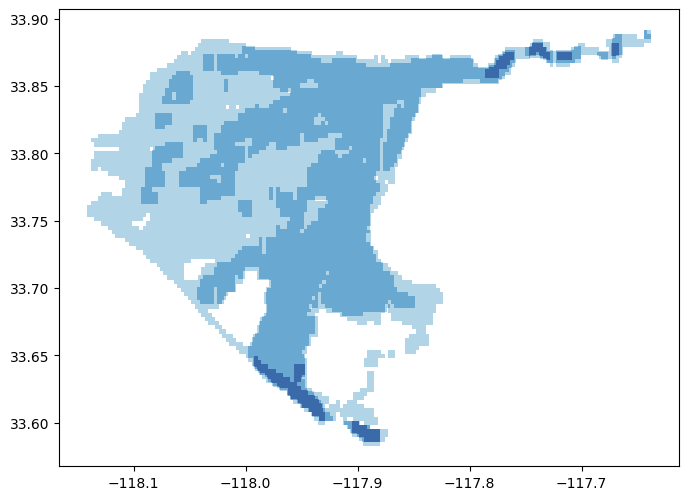

In [3]:
def resample_raster(rasterfile_path, filename, target_path, rescale_factor):
    # first determine pixel size for resampling
    xres = 0
    yres = 0
    
    out = subprocess.run(["gdalinfo","-json",rasterfile_path],stdout=subprocess.PIPE)
    raster_meta = json.loads(out.stdout.decode('utf-8'))
    if 'geoTransform' in raster_meta:
        xres = raster_meta['geoTransform'][1]
        yres = raster_meta['geoTransform'][5]
        xres = xres * rescale_factor
        yres = yres * rescale_factor

    if (xres != 0) and (yres != 0):
        # resample raster
        save_path = target_path +"/"+ filename + f"_resample.tiff"
        subprocess.run(["gdalwarp","-r","bilinear","-of","GTiff","-tr",str(xres),str(yres),rasterfile_path,save_path])

        return save_path, raster_meta

def polygonize_fim(rasterfile_path, target_path):

    # Extract target path and filename from the given raster file path
    # target_path = '/'.join(rasterfile_path.split('/')[:-1])
    filename = rasterfile_path.split("/")[-1].split(".")[-2]

    # Define paths
    resample_path = target_path +"/"+ filename + f"_resample.tiff"
    reclass_file = target_path + "/" + filename + "_reclass.tiff"
    geojson_out = "%s/%s.json" % (target_path, filename)

    for temp_path_ in [resample_path, reclass_file, geojson_out]:
        if os.path.exists(temp_path_):
            os.remove(temp_path_)

    # Resample raster file to 10-times smaller
    resample_path, raster_meta = resample_raster(rasterfile_path, filename, target_path, rescale_factor=4)

    # Reclassify raster
    outfile = "--outfile="+reclass_file
    print(outfile)
    no_data_val = raster_meta['bands'][0]['noDataValue']
    # subprocess.run(["gdal_calc.py","-A",resample_path,outfile,f"--calc=1*(A>0)",f"--NoDataValue={no_data_val}"],stdout=subprocess.PIPE)
    subprocess.run(["gdal_calc.py","-A",resample_path,outfile,f"--calc=-9999*(A<=0)+1*(A>0)",f"--NoDataValue={no_data_val}"],stdout=subprocess.PIPE)
        
    # Polygonize the reclassified raster
    subprocess.run(["gdal_polygonize.py", reclass_file, "-b", "1", geojson_out, filename, "value"])

    inund_polygons = gpd.read_file(geojson_out)

    # If GeoDataFrame has records
    if inund_polygons.shape[0] != 0:
        print("in here")
        inund_polygons = inund_polygons.loc[(inund_polygons['value'] != -9999) & (inund_polygons['value'] != 0)]  # Remove pixels of null value

        # drop invalid geometries
        inund_polygons = inund_polygons.loc[inund_polygons['geometry'].is_valid, :]

        # Coverage for each class of inundation map
        inund_per_cls = inund_polygons.dissolve(by='value')
        inund_per_cls.reset_index(inplace=True)

        # remove all temp files
        os.remove(resample_path)
        os.remove(reclass_file)
        os.remove(geojson_out)

        # inundation_per_cls: GeoDataFrame 
        return inund_per_cls

    else:
        return gpd.GeoDataFrame(data={'value': 1}, index=[0], geometry=[None])
    
def fim_multiple_scenarios(dam_id, input_dir, output_dir):
    
    sce_mh = {'loadCondition': 'MH', 'breachCondition': 'F'}  # Maximun Height scenario
    sce_tas = {'loadCondition': 'TAS', 'breachCondition': 'F'}  # Top of Active Storage scenario
    sce_nh = {'loadCondition': 'NH', 'breachCondition': 'F'}  # Normal Height scenario

    # Maximun Height scenario (weight: 1)
    fim_path_mh = f"{input_dir}/NID_FIM_{sce_mh['loadCondition']}_{sce_mh['breachCondition']}/{sce_mh['loadCondition']}_{sce_mh['breachCondition']}_{dam_id}.tiff"

    fim_gdf_mh = polygonize_fim(fim_path_mh, output_dir)

    fim_gdf_mh['value_mh'] = fim_gdf_mh['value'] * 1
    fim_gdf_mh.drop(columns=['value'], inplace=True)

    # Top of Active Storage scenario (weight: 1)
    fim_path_tas = f"{input_dir}/NID_FIM_{sce_tas['loadCondition']}_{sce_tas['breachCondition']}/{sce_tas['loadCondition']}_{sce_tas['breachCondition']}_{dam_id}.tiff"
    fim_gdf_tas = polygonize_fim(fim_path_tas, output_dir)
    fim_gdf_tas['value_tas'] = fim_gdf_tas['value'] * 1
    fim_gdf_tas.drop(columns=['value'], inplace=True)

    # Normal Height scenario (weight: 1)
    fim_path_nh = f"{input_dir}/NID_FIM_{sce_nh['loadCondition']}_{sce_nh['breachCondition']}/{sce_nh['loadCondition']}_{sce_nh['breachCondition']}_{dam_id}.tiff"
    fim_gdf_nh = polygonize_fim(fim_path_nh, output_dir)
    fim_gdf_nh['value_nh'] = fim_gdf_nh['value'] * 1
    fim_gdf_nh.drop(columns=['value'], inplace=True)
    # Find intersections of inundated area across multiple scenarios
    temp_fim_gdf = gpd.overlay(fim_gdf_nh, fim_gdf_tas, how='union')
    fim_gdf = gpd.overlay(temp_fim_gdf, fim_gdf_mh, how='union')
    fim_gdf.fillna(0, inplace=True)

    # Sum values (1: MH only, 2: MH + TAS , 3: MH + TAS + NH)
    fim_gdf['value'] = fim_gdf.apply(lambda x:x['value_mh'] + x['value_tas'] + x['value_nh'], axis=1)
    fim_gdf.drop(columns=['value_mh', 'value_tas', 'value_nh'], inplace=True)
    fim_gdf['Dam_ID'] = dam_id
        
    return fim_gdf

fim_gdf = fim_multiple_scenarios(dam_id, data_dir, output_dir)

# Plot polygonized inundation risk of a dam failure
color_brewer = ['#9ecae1','#4292c6','#084594']
cm = LinearSegmentedColormap.from_list('cb_', color_brewer, N=3)

fig, ax = plt.subplots(figsize=(8,8))
fim_gdf.plot('value', ax=ax, cmap=cm, alpha=0.8)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.DarkMatterOnlyLabels, crs=fim_gdf.crs, attribution_size=0, zoom=10) # Add basemap
# Hide coordinates in the plot axes
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()


### 1.2. Calculate the highest inundation risk value per census block

In [4]:
# This function returns the id of states that would be impacted by the failure of the dam of interest
def state_num_related_to_fim(fim_gdf, tract_gdf):
    
    tract_df = sedona.createDataFrame(tract_gdf)
    fim_df = sedona.createDataFrame(fim_gdf)

    # Register DataFrames as TempViews for SQL queries
    tract_df.createOrReplaceTempView("tract_df")
    fim_df.createOrReplaceTempView("fim_df")
    
    # SQL query to find intersection of fim geometry with census tracts
    query = """
    SELECT t.GEOID, substring(t.GEOID, 0, 2) as STATE
    FROM tract_df t
    JOIN fim_df f
    ON ST_Intersects(t.geometry, f.geometry)
    """
    
    result = sedona.sql(query)
    result.createOrReplaceTempView("result")
    
    # Extract unique states impacted
    unique_states_query = "SELECT DISTINCT STATE FROM result"
    unique_states_df = sedona.sql(unique_states_query)

    return unique_states_df

# Census tract geometry across the conterminous United States
tract_gdf = gpd.read_file(os.path.join(data_dir, 'census_geometry', 'census_tract_from_api.geojson'))
fim_state = state_num_related_to_fim(fim_gdf, tract_gdf)

fim_state_unique_count = fim_state.count()  # Get the count of unique states

# Load census block geometry of the selected states
if fim_state_unique_count == 1:  # If only one state is associated with the inundation mapping
    block_gdf = gpd.read_file(os.path.join(data_dir, 'census_geometry', f'tl_2020_{fim_state.first()["STATE"]}_tabblock20.geojson'))
elif fim_state_unique_count >= 2:  # If multiple states are associated with the inundation mapping
    block_gdf = pd.DataFrame()
    for state_num in fim_state["STATE"].unique():
        temp_gdf = gpd.read_file(os.path.join(data_dir, 'census_geometry', f'tl_2020_{state_num}_tabblock20.geojson'))
        block_gdf = pd.concat([temp_gdf, block_gdf]).reset_index(drop=True)
    block_gdf = gpd.GeoDataFrame(block_gdf, geometry=block_gdf['geometry'], crs="EPSG:4326")
else:
    raise AttributeError('NO STATE is related to Inundation Mapping')

# Destination dataframe to save the results
fim_geoid_gdf = gpd.GeoDataFrame({'Dam_ID': pd.Series(dtype='str'),
                                  'GEOID': pd.Series(dtype='str'),
                                  'Class': pd.Series(dtype='str')
                                 }
                            )    

# Create STRtree for block_gdf
#block_geoms = pygeos.from_shapely(block_gdf['geometry'].values)
#block_geoms_tree = pygeos.STRtree(block_geoms, leafsize=50)

# Extract census tract intersecting with each class of inundation map
for water_cls in fim_gdf['value'].unique():
    fim_geom_ = fim_gdf.loc[fim_gdf['value'] == water_cls, 'geometry'].unary_union
    
    # Perform spatial join directly with GeoPandas
    fim_geoid_ = gpd.sjoin(block_gdf, gpd.GeoDataFrame({'geometry': [fim_geom_]}), how='inner', predicate='intersects')
    fim_geoid_['Class'] = water_cls
    fim_geoid_['Dam_ID'] = dam_id
    
    fim_geoid_gdf = pd.concat([fim_geoid_, fim_geoid_gdf]).reset_index(drop=True)

### Cleaning output
# Creating the sedona df
df = sedona.createDataFrame(
  fim_geoid_gdf
)

### Sedona optimized data processing
df.createOrReplaceTempView("fim_geoid_gdf")
filtered = sedona.sql("SELECT GEOID, Dam_ID, Class, geometry FROM fim_geoid_gdf")
grouped = filtered.groupBy(['Dam_ID', 'GEOID'])
optimized_query = """
SELECT GEOID, Dam_ID, Class, geometry, subquery.row_num
FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY Dam_ID, GEOID ORDER BY Class DESC) AS row_num
    FROM fim_geoid_gdf
) subquery
WHERE row_num = 1
"""
fim_geoid_gdf = sedona.sql(optimized_query).drop('row_num').drop_duplicates().sort("GEOID")
# print(f"Size of processed dataframe: {fim_geoid_gdf.count()}")
# fim_geoid_gdf = gpd.GeoDataFrame(processed.toPandas(), geometry="geometry")

# This is unnecessary since epsg is set to 4326 on creation of fim_geoid_gdf
# fim_geoid_gdf = fim_geoid_gdf.set_crs(epsg=4326)  

fim_geoid_gdf.select("*").orderBy("GEOID").show(truncate=False, n=10)

26/02/24 20:46:22 WARN TaskSetManager: Stage 3 contains a task of very large size (1650 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:46:23 WARN TaskSetManager: Stage 4 contains a task of very large size (1650 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:46:23 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.
26/02/24 20:46:23 WARN TaskSetManager: Stage 6 contains a task of very large size (1650 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:46:26 WARN TaskSetManager: Stage 17 contains a task of very large size (1650 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:46:26 WARN TaskSetManager: Stage 18 contains a task of very large size (1650 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:46:26 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.
26/02/24 20:46:26 WARN TaskSetManager: Stage 20 contains a task of very large size (1650 

+---------------+-------+-----+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 1.3. Step 1 results (Inundation risk per census block)

26/02/24 20:46:41 WARN TaskSetManager: Stage 31 contains a task of very large size (1140 KiB). The maximum recommended task size is 1000 KiB.
ERROR 1: PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


CRSError: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.

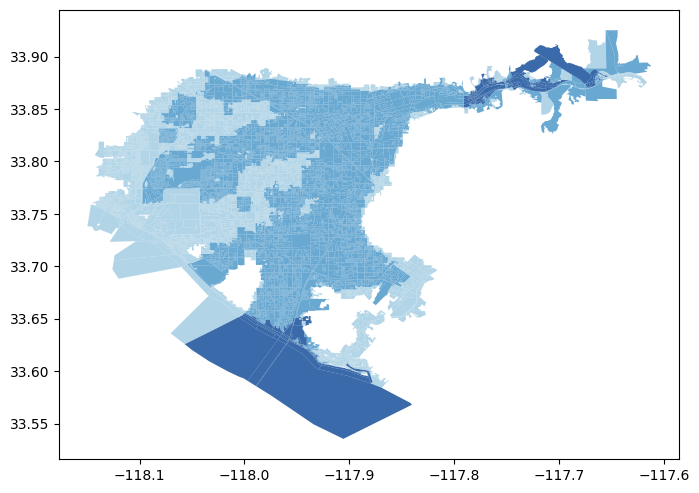

In [5]:
# Plot census block with inundation risk of a dam failure
color_brewer = ['#9ecae1','#4292c6','#084594']
cm = LinearSegmentedColormap.from_list('cb_', color_brewer, N=3)

fig, ax = plt.subplots(figsize=(8,8))
gpd.GeoDataFrame(fim_geoid_gdf.toPandas(), geometry="geometry").plot('Class', ax=ax, cmap=cm, alpha=0.8)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.DarkMatterOnlyLabels, crs=fim_gdf.crs, attribution_size=0, zoom=10)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

## 2. Retrive Census Data

To investigate the social vulnerability of the population at-risk of dam failure, we retrieve the following variables from Census API.

![](https://www.atsdr.cdc.gov/placeandhealth/svi/documentation/SVI-Variables.png?_=02699)

Source: https://www.atsdr.cdc.gov/placeandhealth/svi/documentation/SVI_documentation_2020.html

In [6]:
from sedona.sql.st_functions import ST_Transform


def call_census_table(state_list, table_name, key):
    
    result_df = pd.DataFrame()
    
    # querying at census tract level
    for state in state_list:
        if table_name.startswith('DP'):
            address = f'https://api.census.gov/data/2020/acs/acs5/profile?get=NAME,{table_name}&for=tract:*&in=state:{state}&in=county:*'
        elif table_name.startswith('S'):
            address = f'https://api.census.gov/data/2020/acs/acs5/subject?get=NAME,{table_name}&for=tract:*&in=state:{state}&in=county:*'
        elif table_name.startswith('B'):
            address = f'https://api.census.gov/data/2020/acs/acs5?get=NAME,{table_name}&for=tract:*&in=state:{state}&in=county:*'
        else:
            raise AttributeError('Proper Table Name Is Needed.')
            
        response = requests.get(f'{address}&key={key}').json()
        result_ = pd.DataFrame(response)
        
        result_.columns = response[0]
        result_.drop(0, axis=0, inplace=True)
        
        result_df = pd.concat([result_, result_df]).reset_index(drop=True)
        
    # result_df = result_df.rename(columns={'GEO_ID':'GEOID_T'})
    result_df['GEOID_T'] = result_df.apply(lambda x: x['state'] + x['county'] + x['tract'], axis=1)
    result_df[table_name] = result_df[table_name].astype(float)
        
    return result_df[['GEOID_T', table_name]]


# Employed census tables to calculate each social vulnerabilty related variables.
# str: single variable
# list: [[To be summed and set as numerator], demonimator]  
census_info = {
    "EP_POV150" : [['S1701_C01_040E'], 'S1701_C01_001E'],
    "EP_UNEMP"  : 'DP03_0009PE',
    "EP_HBURD"  : [['S2503_C01_028E', 'S2503_C01_032E', 'S2503_C01_036E', 'S2503_C01_040E'], 
                   'S2503_C01_001E'],
    "EP_NOHSDP" : 'S0601_C01_033E',
    "EP_UNINSUR" : 'S2701_C05_001E',
    "EP_AGE65" : 'S0101_C02_030E',
    "EP_AGE17" : [['B09001_001E'], 
                  'S0601_C01_001E'],
    "EP_DISABL" : 'DP02_0072PE',
    "EP_SNGPNT" : [['B11012_010E', 'B11012_015E'], 'DP02_0001E'],
    "EP_LIMENG" : [['B16005_007E', 'B16005_008E', 'B16005_012E', 'B16005_013E', 'B16005_017E', 'B16005_018E', 
                    'B16005_022E', 'B16005_023E', 'B16005_029E', 'B16005_030E', 'B16005_034E', 'B16005_035E',
                    'B16005_039E', 'B16005_040E', 'B16005_044E', 'B16005_045E'], 
                   'B16005_001E'],
    "EP_MINRTY" : [['DP05_0071E', 'DP05_0078E', 'DP05_0079E', 'DP05_0080E', 
                    'DP05_0081E', 'DP05_0082E', 'DP05_0083E'],
                   'S0601_C01_001E'],
    "EP_MUNIT" : [['DP04_0012E', 'DP04_0013E'], 
                  'DP04_0001E'],
    "EP_MOBILE" : 'DP04_0014PE',
    "EP_CROWD" : [['DP04_0078E', 'DP04_0079E'], 
                  'DP04_0002E'],
    "EP_NOVEH" : 'DP04_0058PE',
    "EP_GROUPQ": [['B26001_001E'], 
                  'S0601_C01_001E']
}


# Calculate GEOID for census tract as the census data is provided based on census tract
# fim_geoid_gdf['GEOID_T'] = fim_geoid_gdf.apply(lambda x:x['GEOID'][0:11], axis=1)
fim_geoid_gdf = fim_geoid_gdf.withColumn("GEOID_T", substring(col("GEOID"), 1, 11))

# List of states that is associated with the dam failure
# state_list = fim_geoid_gdf.apply(lambda x:x['GEOID'][0:2], axis=1).unique()
fim_geoid_sdf = fim_geoid_gdf.withColumn("GEOID_PREFIX", substring(col("GEOID"), 1, 2))
state_list = fim_geoid_sdf.select("GEOID_PREFIX").distinct()

cols = list(census_info.keys())
cols.append('GEOID_T')

'''
This commented cell demonstrates how the census data was retrieved from the Census API.
To avoid potential issue during the API calling, this demonstration loads `census_data.csv`,
which is already retrieved and stored in the repo. 

attr_df = pd.DataFrame({'GEOID_T':fim_geoid_gdf['GEOID_T'].unique().tolist()})
for attr in census_info.keys(): # attr: svi-related census abbriviation on the final table
    print(f'Retrieving {attr} from Census API')
    
    if type(census_info[attr]) == str:
        temp_table = call_census_table(state_list, census_info[attr], API_Key)
        attr_df = attr_df.merge(temp_table, on='GEOID_T')
        attr_df = attr_df.rename(columns={census_info[attr]: attr})
    else:
        for table in census_info[attr][0]: # Retrieve numerator variables
            temp_table = call_census_table(state_list, table, API_Key)
            attr_df = attr_df.merge(temp_table, on='GEOID_T')

        temp_table = call_census_table(state_list, census_info[attr][1], API_Key) # Retrieve denominator variable
        attr_df = attr_df.merge(temp_table, on='GEOID_T')

        # Calculate the ratio of each variable
        attr_df[attr] = attr_df[census_info[attr][0]].sum(axis=1) / attr_df[census_info[attr][1]] * 100

    # Remove intermediate columns used for SVI related census calculation
    attr_df = attr_df[attr_df.columns.intersection(cols)]

    # Replace not valid value (e.g., -666666) from census with nan value
    attr_df[attr] = attr_df.apply(lambda x: float('nan') if x[attr] < 0 else x[attr], axis=1)
'''

# Merge census data with fim_geoid_gdf
# attr_df = pd.read_csv(os.path.join(data_dir, 'census_geometry', 'census_data.csv')) 
# attr_df['GEOID_T'] = attr_df['GEOID_T'].astype(str)
# attr_df['GEOID_T'] = attr_df.apply(lambda x:x['GEOID_T'].zfill(11), axis=1)
# fim_geoid_gdf = fim_geoid_gdf.merge(attr_df, on='GEOID_T')
attr_df = sedona.read.csv(os.path.join(data_dir, 'census_geometry', 'census_data.csv'), header=True, inferSchema=True)
display(attr_df)
attr_df = attr_df.withColumn("GEOID_T", col("GEOID_T").cast("string"))
attr_df = attr_df.withColumn("GEOID_T", lpad(col("GEOID_T"), 11, "0"))
fim_geoid_gdf = fim_geoid_gdf.join(attr_df, on="GEOID_T", how="inner")

# Reproject fim_geoid to EPSG:5070, NAD83 / Conus Albers (meters)
fim_geoid_gdf = fim_geoid_gdf.withColumn("geometry", ST_Transform(col("geometry"), lit("EPSG:4326"), lit("EPSG:5070")))
# fim_geoid_gdf = fim_geoid_gdf.to_crs(epsg=5070)
fim_geoid_gdf.show(n=3)


DataFrame[GEOID_T: bigint, EP_POV150: double, EP_UNEMP: double, EP_HBURD: double, EP_NOHSDP: double, EP_UNINSUR: double, EP_AGE65: double, EP_AGE17: double, EP_DISABL: double, EP_SNGPNT: double, EP_LIMENG: double, EP_MINRTY: double, EP_MUNIT: double, EP_MOBILE: double, EP_CROWD: double, EP_NOVEH: double, EP_GROUPQ: double]

26/02/24 20:47:51 WARN TaskSetManager: Stage 41 contains a task of very large size (1140 KiB). The maximum recommended task size is 1000 KiB.
[Stage 46:>                                                         (0 + 1) / 1]

+-----------+---------------+-------+-----+--------------------+-----------+--------+-----------+---------+----------+--------+----------+---------+-----------+-----------+-----------+-----------+---------+-----------+--------+-----------+
|    GEOID_T|          GEOID| Dam_ID|Class|            geometry|  EP_POV150|EP_UNEMP|   EP_HBURD|EP_NOHSDP|EP_UNINSUR|EP_AGE65|  EP_AGE17|EP_DISABL|  EP_SNGPNT|  EP_LIMENG|  EP_MINRTY|   EP_MUNIT|EP_MOBILE|   EP_CROWD|EP_NOVEH|  EP_GROUPQ|
+-----------+---------------+-------+-----+--------------------+-----------+--------+-----------+---------+----------+--------+----------+---------+-----------+-----------+-----------+-----------+---------+-----------+--------+-----------+
|06059074005|060590740054004|CA10022|  2.0|POLYGON ((-199597...|22.59819533|     7.2|26.04938272|     37.6|      17.0|    11.9|22.9453803|     10.8|5.802469136|22.26158038|88.83358857|25.78215527|      0.5|37.65432099|    11.3|3.815722307|
|06059074005|060590740054001|CA10022|  2

26/02/24 20:48:14 WARN TaskSetManager: Stage 47 contains a task of very large size (1140 KiB). The maximum recommended task size is 1000 KiB.
ERROR 1: PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


CRSError: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /home/exouser/floability-base-dir/floability_instance_20260224_202840_445209/current_conda_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.

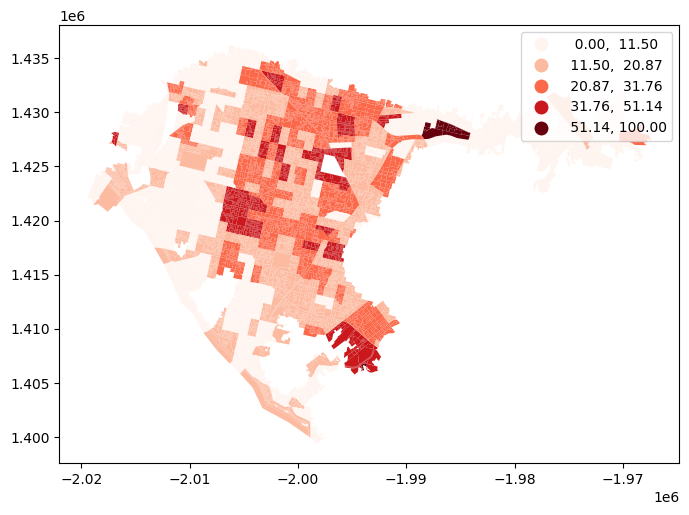

In [7]:
# Plot an example of census variable (POV150: Below 150% Poverty)
fig, ax = plt.subplots(figsize=(8,8))

converted = gpd.GeoDataFrame(fim_geoid_gdf.toPandas(), geometry="geometry")
converted.plot('EP_POV150', ax=ax, scheme='naturalbreaks', cmap='Reds', legend=True)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.PositronOnlyLabels, crs=5070, attribution_size=0, zoom=10)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

## 3. Relationship between social vulnerabilty of population and inundation risk of dam failure

Based on two well-known metrics (Bivariate Moran’s I and Bivariate Local Indicator of Spatial Association (LISA)) spatial correlation step investigates the relationship between the inundation risk and social vulnerability of each census variable at the census block level. Each metric takes two input variables: 1) the potential risk of dam failure-induced flooding and 2) one out of 16 census data related to social vulnerability. Here, we employed the Queen’s case as spatial contiguity for calculating the Bivariate Moran’s I and LISA.

In [8]:
import time
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import contextily as cx
from pyspark.sql.functions import col, expr
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, ArrayType
from shapely.wkt import loads
import libpysal
import esda

def calculate_bivariate_Moran_I_and_LISA(dam_id, census_info, fim_df, dams_gdf):
    if "geometry_wkt" not in fim_df.columns:
        fim_df = fim_df.withColumn("geometry_wkt", expr("ST_AsText(geometry)"))
        fim_df = fim_df.drop("geometry").withColumnRenamed("geometry_wkt", "geometry")
    
    fim_df_filtered = fim_df.filter(col("Dam_ID") == dam_id)
    
    census_cols = list(census_info.keys())
    stack_expr = ", ".join([f"'{col_name}', {col_name}" for col_name in census_cols])
    fim_df_stacked = fim_df_filtered.selectExpr(
        "Dam_ID", "GEOID", "Class", "geometry",
        f"stack({len(census_cols)}, {stack_expr}) as (census_variable, census_value)"
    )
    
    result_schema = StructType([
        StructField("Dam_ID", StringType(), True),
        StructField("census_variable", StringType(), True),
        StructField("MI", DoubleType(), True),
        StructField("pval", DoubleType(), True),
        StructField("LISA", ArrayType(StringType()), True),
        StructField("GEOID", ArrayType(StringType()), True),
    ])
    
    def compute_stats(pdf: pd.DataFrame) -> pd.DataFrame:
        if len(pdf) == 0:
            return pd.DataFrame({
                "Dam_ID": [dam_id],
                "census_variable": [pdf["census_variable"].iloc[0] if not pdf.empty else ""],
                "MI": [None],
                "pval": [None],
                "LISA": [[]],
                "GEOID": [[]]
            })
        
        valid_pdf = pdf.loc[(~pdf['census_value'].isna()) & (pdf['census_value'] >= 0),
                          ['Dam_ID', 'GEOID', 'Class', 'census_value', 'geometry']].reset_index(drop=True)
        
        if len(valid_pdf) < 2:
            return pd.DataFrame({
                "Dam_ID": [dam_id],
                "census_variable": [pdf["census_variable"].iloc[0]],
                "MI": [None],
                "pval": [None],
                "LISA": [[]],
                "GEOID": [[]]
            })
        
        valid_pdf["geometry"] = valid_pdf["geometry"].apply(loads)
        
        try:
            w = libpysal.weights.Queen.from_dataframe(valid_pdf, use_index=True)
            if hasattr(w, 'islands') and len(w.islands) > 0:
                w.fix_islands()
            
            bv_mi = esda.Moran_BV(valid_pdf['Class'], valid_pdf['census_value'], w)
            
            bv_lm = esda.Moran_Local_BV(valid_pdf['Class'], valid_pdf['census_value'], w, seed=17)
            
            lm_dict = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
            LISA_list = []
            for i in range(len(valid_pdf)):
                if bv_lm.p_sim[i] < 0.05:
                    LISA_list.append(lm_dict.get(bv_lm.q[i], 'NA'))
                else:
                    LISA_list.append("Not_Sig")
            
            return pd.DataFrame({
                "Dam_ID": [valid_pdf["Dam_ID"].iloc[0]],
                "census_variable": [pdf["census_variable"].iloc[0]],
                "MI": [bv_mi.I],
                "pval": [bv_mi.p_z_sim],
                "LISA": [LISA_list],
                "GEOID": [list(valid_pdf.GEOID)]
            })
        
        except Exception as e:
            print(f"Error computing statistics for {pdf['census_variable'].iloc[0]}: {e}")
            return pd.DataFrame({
                "Dam_ID": [dam_id],
                "census_variable": [pdf["census_variable"].iloc[0]],
                "MI": [None],
                "pval": [None],
                "LISA": [[]],
                "GEOID": [[]]
            })
    
    result_df = fim_df_stacked.groupBy("Dam_ID", "census_variable").applyInPandas(compute_stats, schema=result_schema)
    
    final_result_pd = result_df.toPandas()
    
    mi_pivot = final_result_pd.pivot(index='Dam_ID', columns='census_variable', values='MI')
    mi_pivot.columns = [f"MI_{column_name.split('_')[1]}" for column_name in mi_pivot.columns]
    
    pval_pivot = final_result_pd.pivot(index='Dam_ID', columns='census_variable', values='pval')
    pval_pivot.columns = [f"pval_{column_name.split('_')[1]}" for column_name in pval_pivot.columns]
    
    new_dams = mi_pivot.merge(pval_pivot, left_index=True, right_index=True).reset_index()
    dam_local = dams_gdf.loc[dams_gdf['ID'] == dam_id].copy()
    
    for column_name in new_dams.columns:
        if column_name != 'Dam_ID' and len(new_dams) > 0:
            dam_local[column_name] = new_dams[column_name].iloc[0]
    
    original_gdf = fim_df.toPandas()
    
    if not isinstance(original_gdf, gpd.GeoDataFrame):
        try:
            original_gdf["geometry"] = original_gdf["geometry"].apply(loads)
            original_gdf = gpd.GeoDataFrame(original_gdf, geometry="geometry")
        except Exception as e:
            print(f"Error converting to GeoDataFrame: {e}")
    
    new_fim_local = original_gdf[['GEOID', 'geometry']].copy()
    if 'Class' in original_gdf.columns:
        new_fim_local['Class'] = original_gdf['Class']
    
    for idx, row in final_result_pd.iterrows():
        if len(row['LISA']) == 0 or len(row['GEOID']) == 0:
            continue
        
        census_var = row['census_variable']
        new_col = f"LISA_{census_var.split('_')[1]}"
        
        lisa_mapping = dict(zip(row['GEOID'], row['LISA']))
        
        new_fim_local[new_col] = new_fim_local['GEOID'].map(lisa_mapping)
    
    new_fim_local = new_fim_local.dropna(how='all', subset=[col for col in new_fim_local.columns if col.startswith('LISA_')])
    
    fim_geoid_local = gpd.GeoDataFrame(new_fim_local, geometry='geometry')
    
    return dam_local, fim_geoid_local

start = time.time()
mi, lm = calculate_bivariate_Moran_I_and_LISA(dam_id, census_info, fim_geoid_gdf, fed_dams)
end = time.time()
print(f"Calculation time: {end - start:.2f} seconds")
print("\nCensus area LISA classifications (lm):")
lm.head()


26/02/24 20:48:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/02/24 20:48:39 WARN TaskSetManager: Stage 53 contains a task of very large size (1140 KiB). The maximum recommended task size is 1000 KiB.
26/02/24 20:48:57 WARN TaskSetManager: Stage 62 contains a task of very large size (1140 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Calculation time: 19.57 seconds

Census area LISA classifications (lm):


,GEOID,geometry,Class,LISA_MOBILE,LISA_NOVEH,LISA_AGE17,LISA_MINRTY,LISA_GROUPQ,LISA_POV150,LISA_SNGPNT,LISA_DISABL,LISA_AGE65,LISA_UNINSUR,LISA_NOHSDP,LISA_UNEMP,LISA_HBURD,LISA_MUNIT,LISA_CROWD,LISA_LIMENG
0,060590740054004,"POLYGON ((-1995973.11 1412695.474, -1995946.33...",2.0,Not_Sig,Not_Sig,Not_Sig,HH,Not_Sig,Not_Sig,Not_Sig,Not_Sig,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,HH,Not_Sig
1,060590740054001,"POLYGON ((-1996440.717 1412756.66, -1996434.38...",2.0,Not_Sig,HH,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,HH,HH
2,060590740052012,"POLYGON ((-1996229.238 1413263.59, -1996149.13...",2.0,Not_Sig,HH,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,HH,HH
3,060590740052010,"POLYGON ((-1996295.559 1413376.67, -1996286.71...",2.0,Not_Sig,HH,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,Not_Sig,HH,HH,HH,Not_Sig,Not_Sig,HH,HH
4,060590740051013,"POLYGON ((-1995638.258 1413743.883, -1995596.1...",2.0,Not_Sig,HH,Not_Sig,HH,HH,Not_Sig,Not_Sig,Not_Sig,HL,HH,HH,Not_Sig,Not_Sig,HH,HH,HH


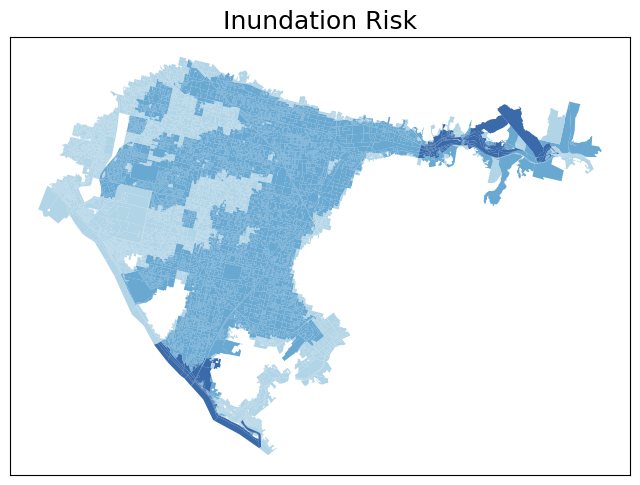

In [9]:
# Plot Inundation Risk

color_brewer = ['#9ecae1','#4292c6','#084594']
cm = LinearSegmentedColormap.from_list('cb_', color_brewer, N=3)

fig, ax = plt.subplots(figsize=(8,8))
lm.plot('Class', ax=ax, cmap=cm, alpha=0.8)
mi_plot = mi.to_crs(epsg=5070)
mi_plot.plot(marker="*", color='red', markersize=200, ax=ax)
# cx.add_basemap(ax=ax, source=cx.providers.CartoDB.PositronOnlyLabels, crs=lm.crs, attribution_size=0, zoom=10)
ax.set_title('Inundation Risk', fontsize=18)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()


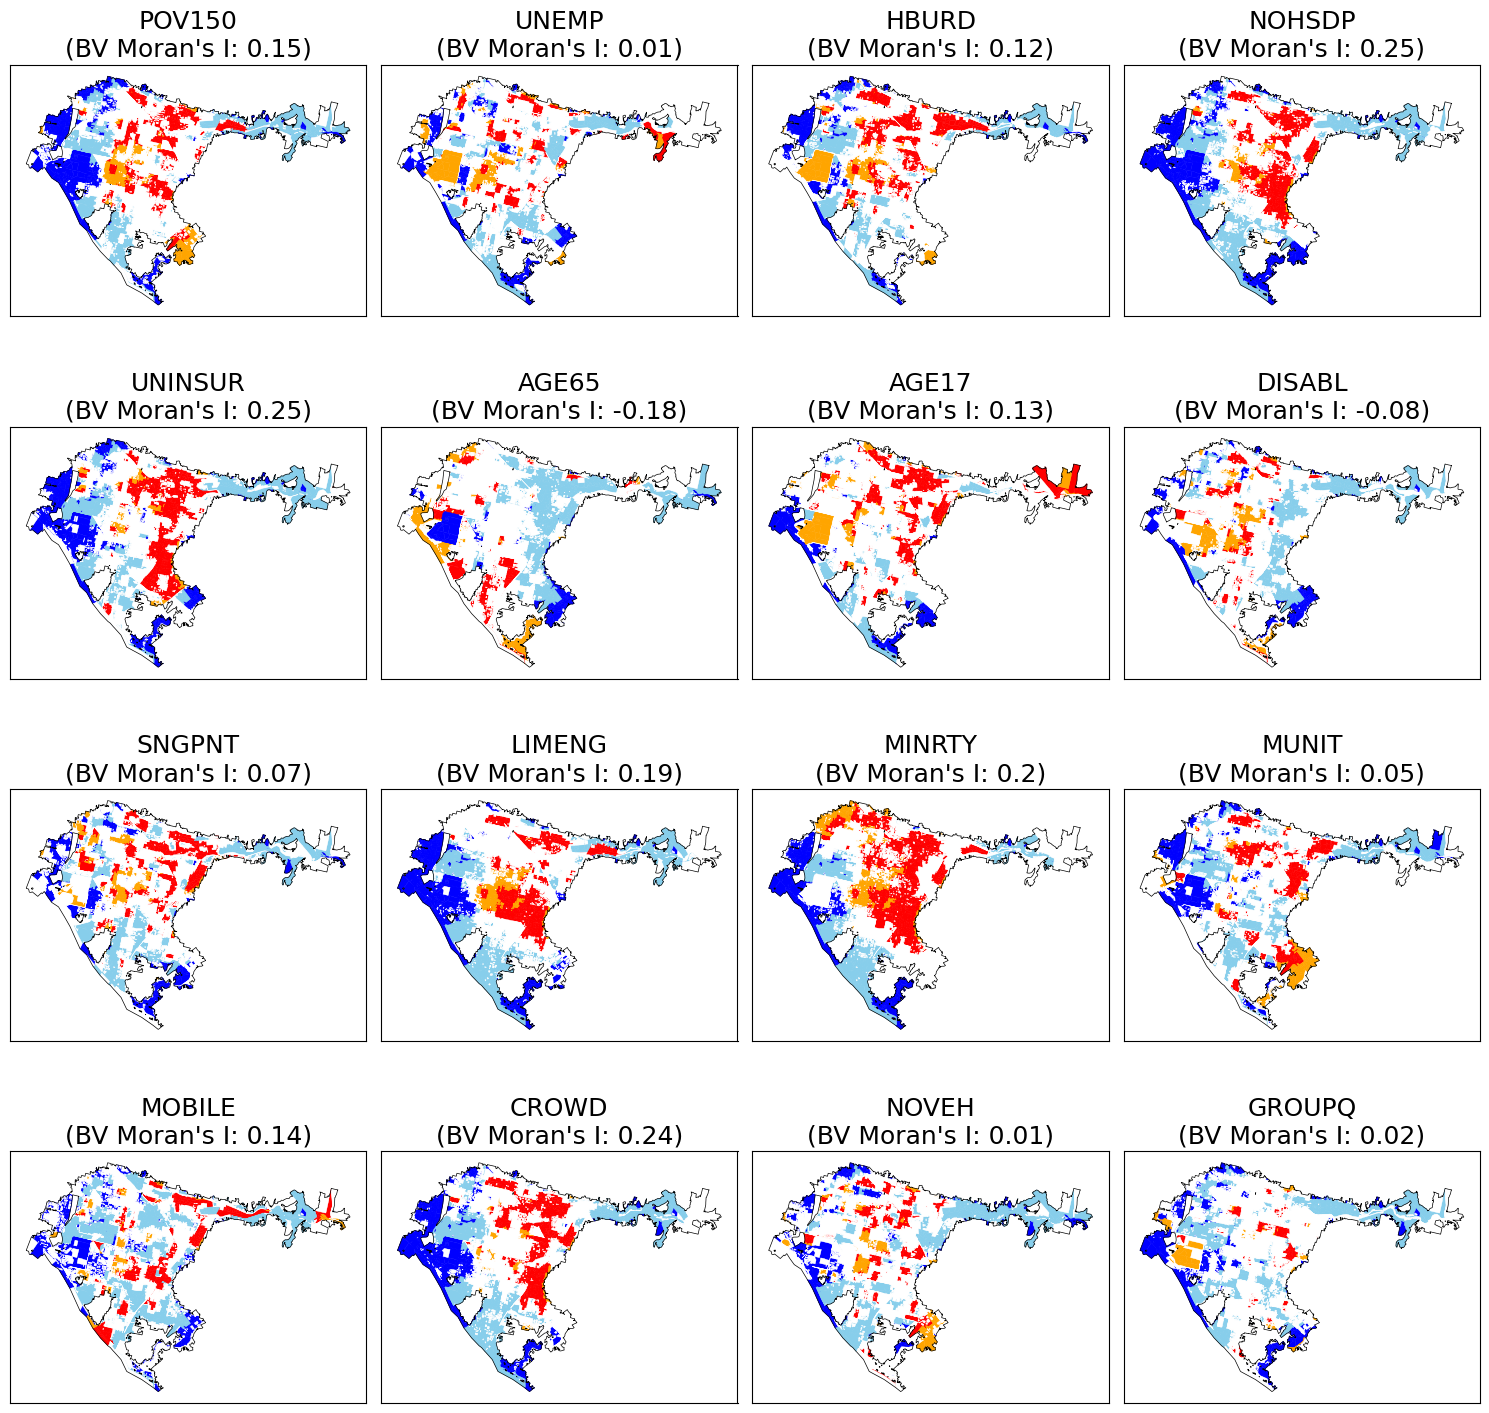

In [10]:
from shapely.ops import unary_union

# Plot Bivariate LISA
'''
# The title of each cell provides Bivariate Moran's I 
# Census block color codes:
## Red: HH cluster (high inundation risk and high social vulnerability)
## Skyblue: HL cluster (high inundation risk and low social vulnerability)
## Orange: LH cluster (low inundation risk and high social vulnerability)
## Blue: LL cluster (low inundation risk and low social vulnerability)
'''
plot_cols = [ col.split('_')[1] for col in census_info.keys()]

# LISA
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.reshape(-1)

lisa_color = {'HH': 'red', 'LL': 'blue', 'HL': 'skyblue', 'LH': 'orange', 'Not_Sig': 'white'}
boundary_gdf = gpd.GeoDataFrame([0], geometry=[unary_union(lm['geometry'])])

for idx, val in enumerate(plot_cols):
    for key in lisa_color.keys():
        lm.loc[(lm[f'LISA_{val}'] == key)].plot(ax=axes[idx], color=lisa_color[key], edgecolor='face', lw=0.3, legend=True)

    moran_i_value = float(mi_plot.loc[mi_plot['ID'] == dam_id, f'MI_{val}'].values[0])
    boundary_gdf.boundary.plot(ax=axes[idx], lw=0.5, color='black')
    axes[idx].set_title(label=f"{val}\n(BV Moran's I: {__builtins__.round(moran_i_value, 2)})",
                        fontsize=18)
    mi_plot.plot(marker="*", color='black', markersize=400, ax=axes[idx])

    axes[idx].get_xaxis().set_visible(False)
    axes[idx].get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# Done